In [1]:
from ROCRL import ROCRLLearner
from ROCRL_environment import LinearSEMGenerator, LinearUtility, ROCRLEnvironment
from metrics import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
n_latents = 5
d_obs = 10
sem = LinearSEMGenerator(n = n_latents, d = d_obs, seed = 3, latent_noise_std = 1.0)
util = LinearUtility(n = n_latents, noise_std = 1.0, theta_dist = "ones", seed = 1)
env = ROCRLEnvironment(sem = sem, utility = util)

In [3]:
intervention_type = "soft"  
T0 = 3000

learner = ROCRLLearner(
    n=n_latents,
    d=d_obs,
    intervention_type= intervention_type,
    gamma=0.5,
    lam=1e-3,
    seed=0,
    dim_reduction=True,
    hard_unmixing=False,
    T0=T0,
)

print("True adjacency:")
print((np.abs(sem.B) > 1e-10).astype(int).T)
print("Theta:", util.theta)


kind_of = lambda a: ("none" if len(a) == 0 else intervention_type)

actions = list(powerset_actions(n_latents))
vals = np.array([expected_utility_under_action(env, a, kind_of(a)) for a in actions])

best_idx = int(np.argmax(vals))
benchmark_action = actions[best_idx]
benchmark_reward = float(vals[best_idx])

# show top-k
k = min(5, len(actions))
top_idx = np.argsort(vals)[::-1][:k]
bottom_idx = np.argsort(vals)[:k]

print(f"Computed exact E[U] for all {len(actions)} actions (kind='{intervention_type}' for non-empty).")
print("\nTop actions:")
for rank, idx in enumerate(top_idx):
    print(f"{rank:2d}: a={fmt_action(actions[idx])}   E[U]={vals[idx]:.6f}")
print("\nBottom actions:")
for rank, idx in enumerate(bottom_idx):
    print(f"{rank:2d}: a={fmt_action(actions[idx])}   E[U]={vals[idx]:.6f}")


True adjacency:
[[0 0 1 0 1]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 0 0 0 1]
 [0 0 0 0 0]]
Theta: [1. 1. 1. 1. 1.]
Computed exact E[U] for all 32 actions (kind='soft' for non-empty).

Top actions:
 0: a=∅   E[U]=4.917022
 1: a={0,1}   E[U]=4.917022
 2: a={0}   E[U]=4.917022
 3: a={1}   E[U]=4.917022
 4: a={1,2}   E[U]=4.522476

Bottom actions:
 0: a={0,1,2,3,4}   E[U]=3.162059
 1: a={0,2,3,4}   E[U]=3.162059
 2: a={2,3,4}   E[U]=3.162059
 3: a={1,2,3,4}   E[U]=3.162059
 4: a={0,1,2,4}   E[U]=3.454814


Forced exploration rounds: 18000
Initial cumulative regret: 6065.2676825472645


/var/folders/2p/vdr0vt8x5xj0cn311r3j9hmr0000gn/T/ipykernel_53289/2808851236.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  utility_obs = float(z_sample @ env.utility.theta)


Round 5
  action: frozenset({1, 2, 3, 4})
mode: ucb
  total samples: 18005
Cumulative regret: 6074.042497989026
theta_hat: [ 1.78493952  2.25251571  0.51024559 -1.58418989  0.74614291]
Round 10
  action: frozenset({1, 2, 3, 4})
mode: ucb
  total samples: 18010
Cumulative regret: 6082.817313430787
theta_hat: [ 1.78481944  2.25300963  0.51019806 -1.58459998  0.7461617 ]
Round 15
  action: frozenset({1, 2, 3, 4})
mode: ucb
  total samples: 18015
Cumulative regret: 6091.5921288725485
theta_hat: [ 1.78489174  2.25299247  0.5102285  -1.58449149  0.74615901]
Round 20
  action: frozenset({1, 2, 3, 4})
mode: ucb
  total samples: 18020
Cumulative regret: 6100.36694431431
theta_hat: [ 1.78491765  2.25285442  0.51025045 -1.58441197  0.74618889]


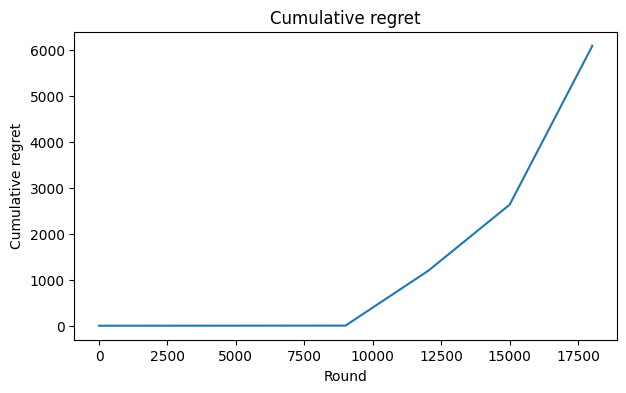

In [4]:
T = 20

actions_taken = []
expected_rewards = []
instant_regret = []

g = sem.G
learner.seed_initial_pools(
    env = env,
    mixing_matrix = g,
    kind = intervention_type,
    benchmark_action = benchmark_action
)

print("Forced exploration rounds:", len(learner.X_all))
print("Initial cumulative regret:", learner.cum_regret[-1])

for t in range(T):
    a = learner.learn()
    actions_taken.append(a)
    z_sample = sem.sample_latents(1, a)
    utility_obs = float(z_sample @ env.utility.theta)
    #print("utility_obs:", utility_obs)
    if env.utility.noise_std > 0:
        utility_obs += float(np.random.uniform(0.0, env.utility.noise_std))
    learner.apply_action_and_update_pools(a, z_sample, g, utility_obs)
    learner.record_regret(env, a, kind_of(a))

    if (t + 1) % 5 == 0:
        print(f"Round {t+1}")
        print("  action:", a)
        print("mode:", learner.last_decision_mode)
        print("  total samples:", len(learner.X_all))
        print("Cumulative regret:", learner.cum_regret[-1])
        print("theta_hat:", learner.theta_hat)
        #print("  current topo:", learner.crl.topo)
        #print("  current dag:\n", learner.crl.dag_adj)

plt.figure(figsize=(7, 4))
plt.plot(learner.cum_regret)
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.title("Cumulative regret")
plt.show()

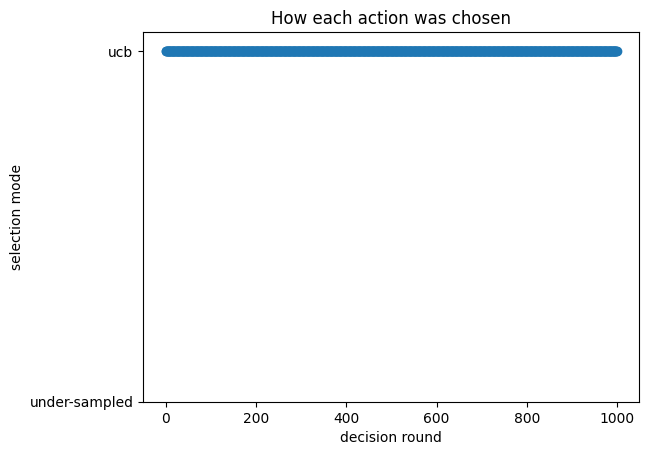

In [12]:
import matplotlib.pyplot as plt

mode_numeric = [0 if rec.mode == "under_sampled" else 1 for rec in learner.decision_history]

plt.plot(mode_numeric, marker="o", linestyle="none")
plt.yticks([0, 1], ["under-sampled", "ucb"])
plt.xlabel("decision round")
plt.ylabel("selection mode")
plt.title("How each action was chosen")
plt.show()

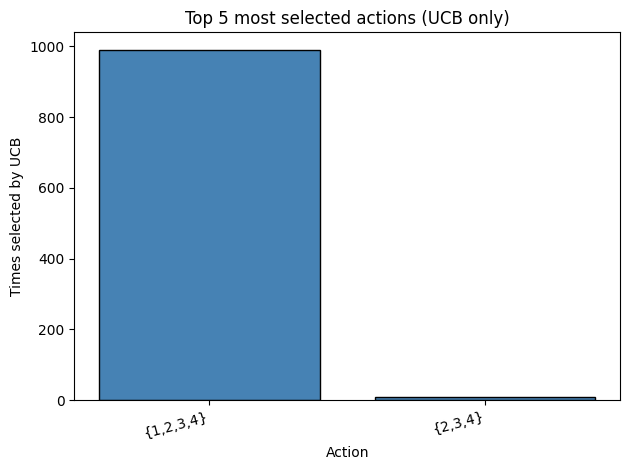

In [14]:
from collections import Counter
def action_to_label(a):
    if len(a) == 0:
        return "∅ (obs)"
    return "{" + ",".join(map(str, sorted(a))) + "}"
# Only actions that were selected by UCB (exclude under_sampled / forced exploration)
ucb_actions = [rec.action for rec in learner.decision_history if rec.mode == "ucb"]
counts = Counter(ucb_actions)
top5 = counts.most_common(5)
labels = [action_to_label(a) for a, _ in top5]
values = [c for _, c in top5]
fig, ax = plt.subplots()
ax.bar(labels, values, color="steelblue", edgecolor="black")
ax.set_xlabel("Action")
ax.set_ylabel("Times selected by UCB")
ax.set_title("Top 5 most selected actions (UCB only)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [17]:
for t in range(-5, 0):
    print("round", learner.round_history[t])
    print("action", learner.decision_history[t].action)
    print("A changed", np.max(np.abs(learner.A_hat_history[t] - learner.A_hat_history[t-1])) if t != -5 else None)
    print("nu changed", np.max(np.abs(learner.nu_hat_history[t] - learner.nu_hat_history[t-1])) if t != -5 else None)
    print()

round 18995
action frozenset({1, 2, 3, 4})
A changed None
nu changed None

round 18996
action frozenset({1, 2, 3, 4})
A changed 2.343135446543354e-05
nu changed 2.943867909532827e-05

round 18997
action frozenset({1, 2, 3, 4})
A changed 5.1315748108626824e-05
nu changed 4.2635482338182484e-05

round 18998
action frozenset({1, 2, 3, 4})
A changed 6.557088183845039e-05
nu changed 1.5082723174630885e-05

round 18999
action frozenset({1, 2, 3, 4})
A changed 3.774757007063423e-05
nu changed 7.66936440999011e-06



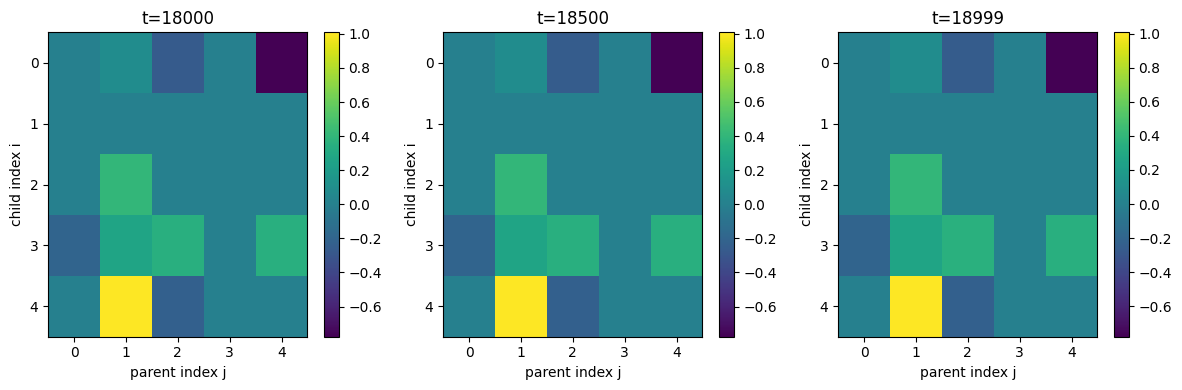

In [16]:
import matplotlib.pyplot as plt
checkpoints = [0, len(learner.A_hat_history)//2, len(learner.A_hat_history)-1]


fig, axes = plt.subplots(1, len(checkpoints), figsize=(4 * len(checkpoints), 4))
if len(checkpoints) == 1:
    axes = [axes]

for ax, k in zip(axes, checkpoints):
    im = ax.imshow(learner.A_hat_history[k], aspect="auto")
    ax.set_title(f"t={learner.round_history[k]}")
    ax.set_xlabel("parent index j")
    ax.set_ylabel("child index i")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()